In [11]:
import json
import os

filename = '/logs/3/2026-07-17_17-12-49_all/history.json'

path = os.getcwd().split('/')[:-3]
filename = '/'.join(path) + filename

with open(filename, 'r') as f:
    history = json.load(f)


In [4]:
import matplotlib.pyplot as plt
import numpy as np

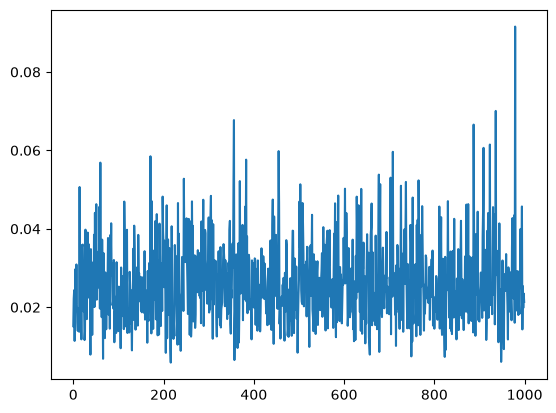

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot([generation['fitness'] for generation in history])

In [13]:
def plot_key_change(key):
    vals =[]
    for generation in history:
        gen_vals = np.mean([result[0][key] for result in generation['results']])
        vals.append(gen_vals)
    plt.plot(vals)
    plt.title(key)
    plt.show()

In [6]:
rollouts = list(ds.iter_rollouts())

In [ ]:
from sysid.data_interface import SysidDSInterface
from sysid.config import CONTROL_HZ
from sysid.env import Env
import time
import json
from tqdm import tqdm


params = {'kp': 56.121566743762834, 'kv': 2.8935209569975355, 'damping': 0.17889452739994438, 'frictionloss': 0.0072408653310164755, 'armature': 0.014643797951585229, 'force_limit': 2.746855360183254}
# params = {'kp': 56.121566743762834, 'kv': 2.8935209569975355, 'damping': 0.17889452739994438, 'frictionloss': 0.0072408653310164755, 'armature': 0.014643797951585229, 'force_limit': 1.9}§§
params = {'kp': 58.92765232815373, 'kv': 3.0381973784993614, 'damping': 0.1878392768713079, 'frictionloss': 0.007602909532609417, 'armature': 0.01537598974017713, 'force_limit': 2.884198482904848}
if __name__ == '__main__':
    ds = SysidDSInterface(filter_short=True)
    env = Env(params=params)

    data = {
        'dataset': 'simulation',
        'config': ds.config,
        'data': [],
    }

    print(f'Collecting {len(ds)} rollouts...')
    pbar = tqdm(total=len(ds))

    for rollout in ds.iter_rollouts():
        pbar.update(1)
        env.reset()

        rollout_data = {
            'type': rollout['type'],
            'actions': [],
            'sim_states': [],
            'real_states': [],
        }
        for action, real_state in zip(rollout['actions'], rollout['sensor_data']):
            sim_states = env.step(action)
            rollout_data['actions'].append(action)
            rollout_data['sim_states'].append(sim_states.tolist())
            rollout_data['real_states'].append(real_state)

        data['data'].append(rollout_data)

    pbar.close()

100%|██████████| 82/82 [00:00<00:00, 98.54it/s] 


In [24]:
rollout['type']

'drop'

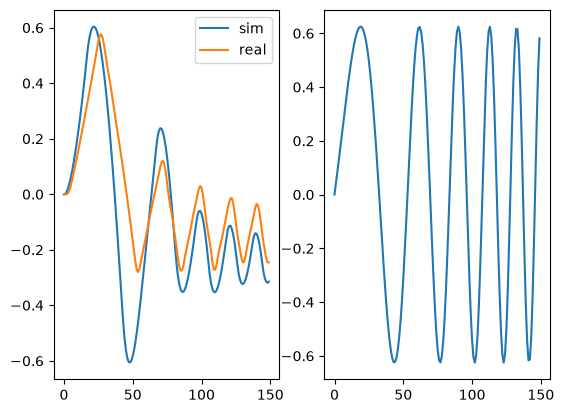

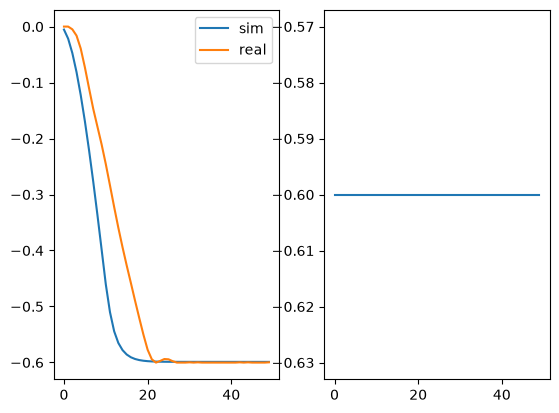

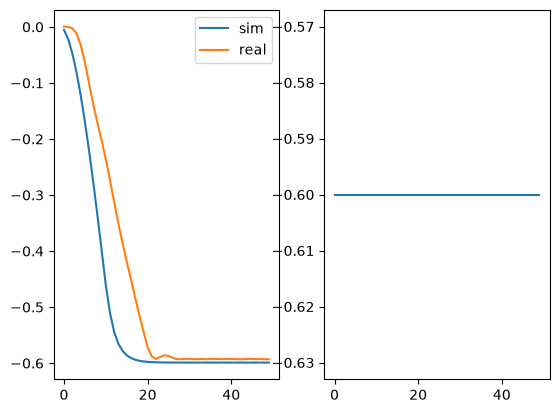

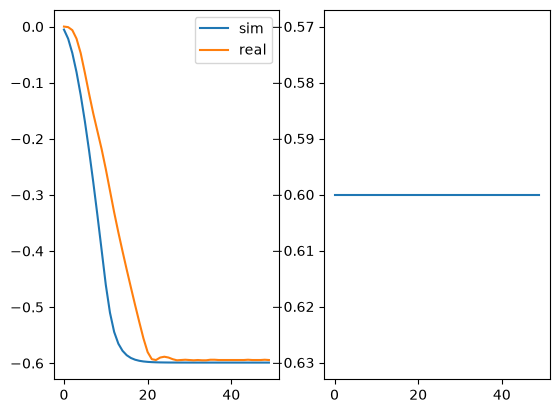

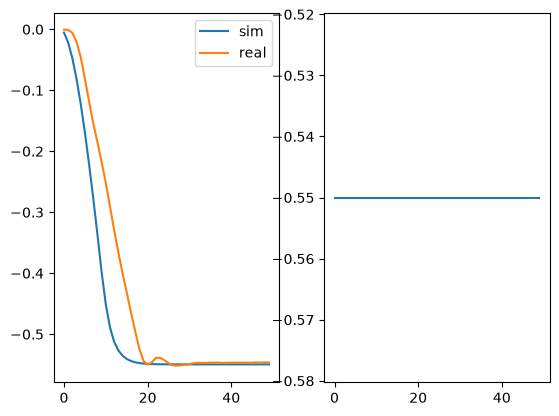

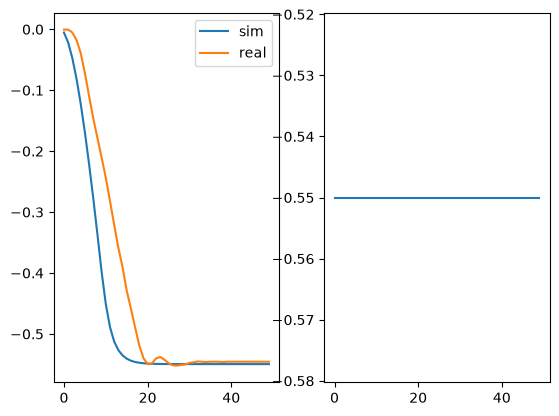

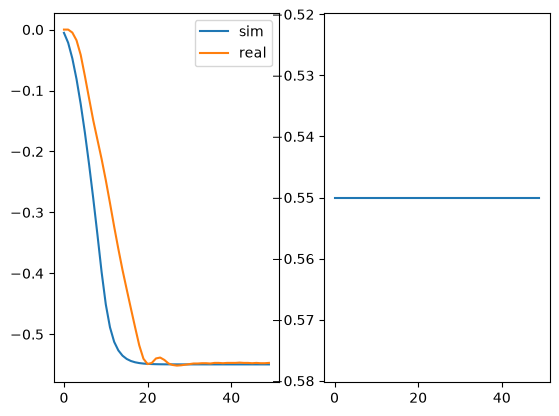

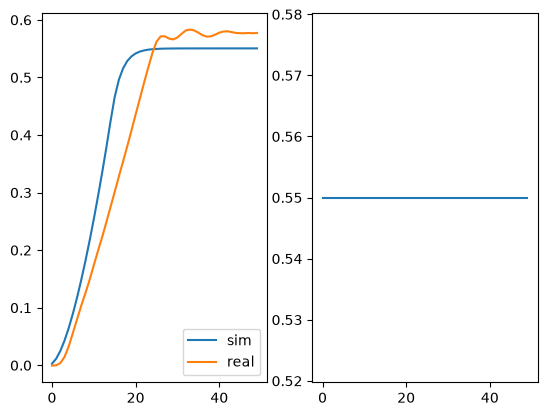

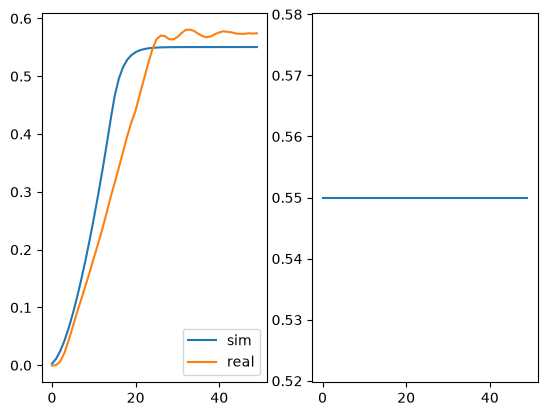

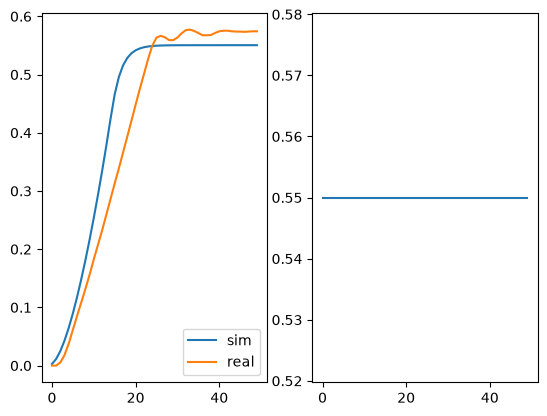

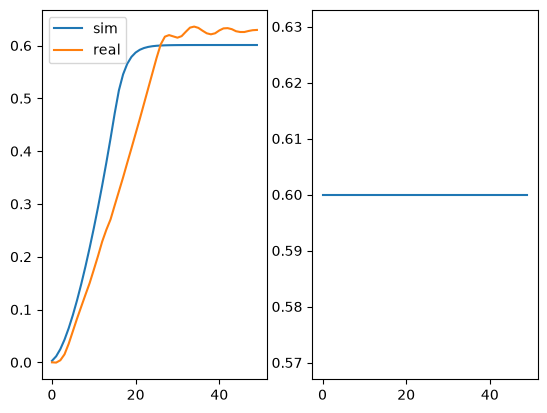

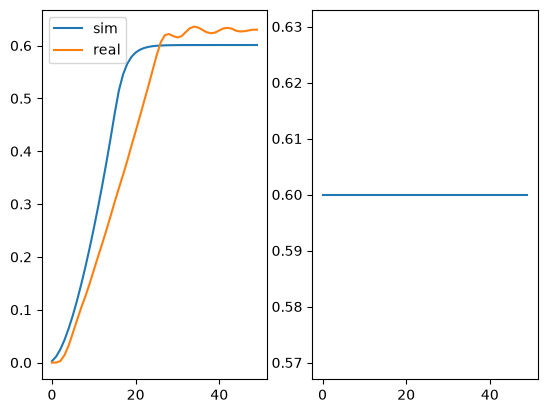

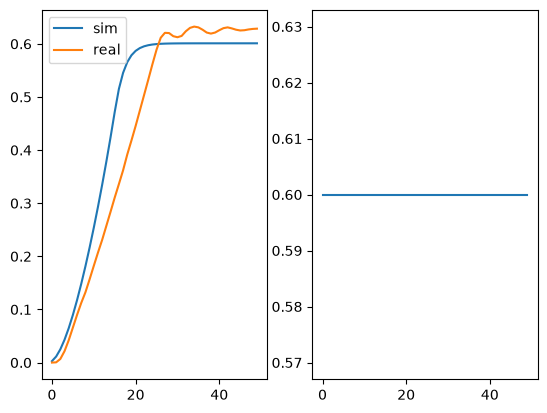

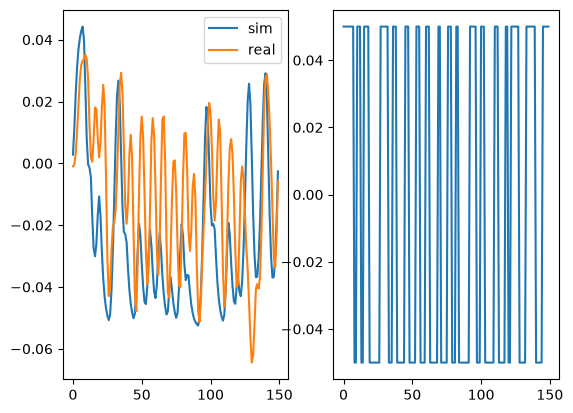

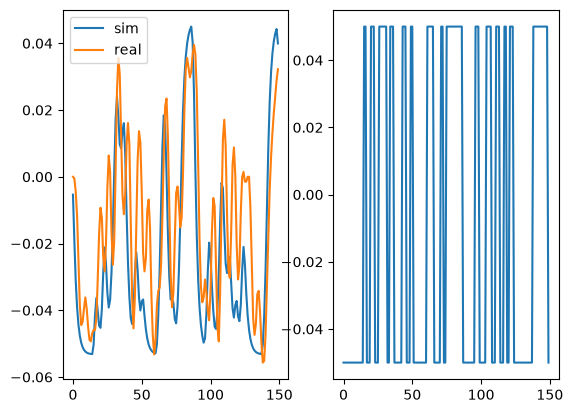

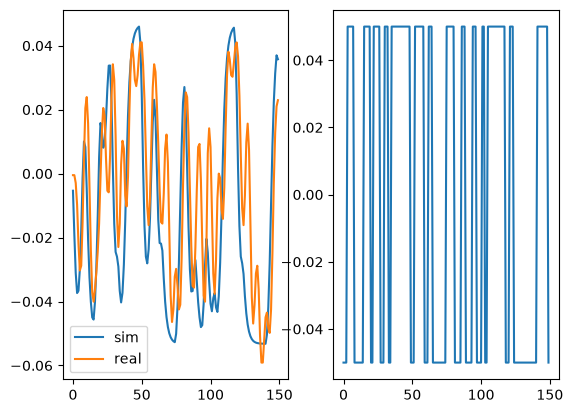

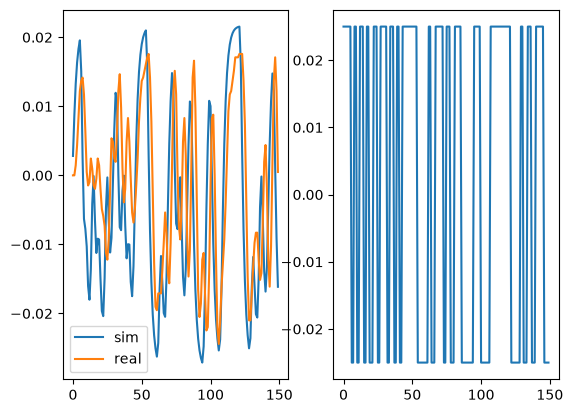

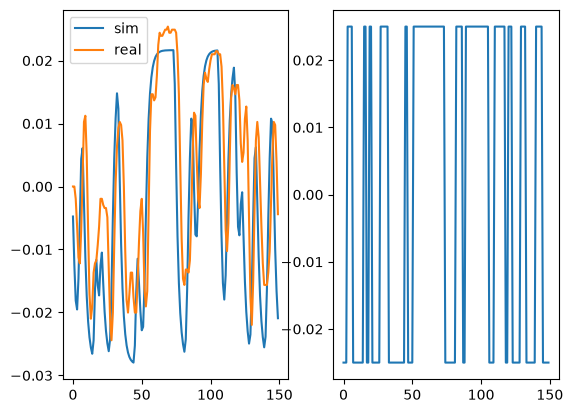

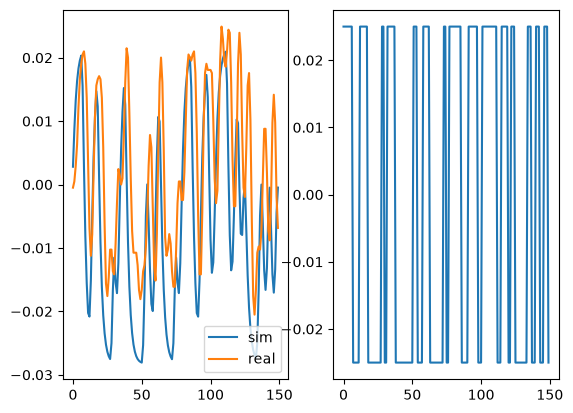

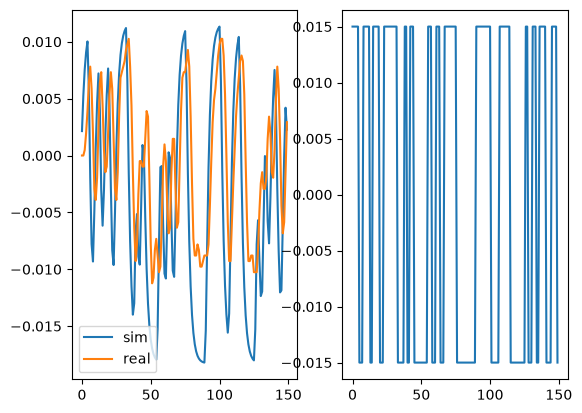

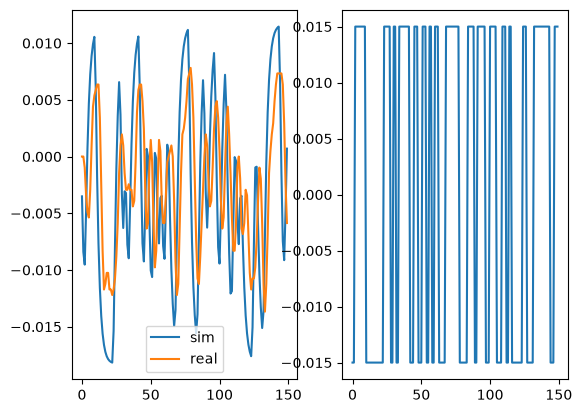

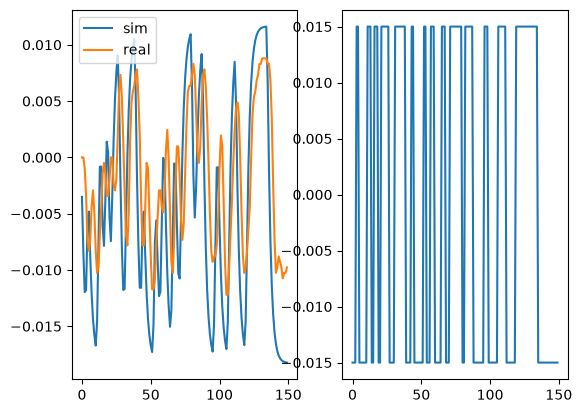

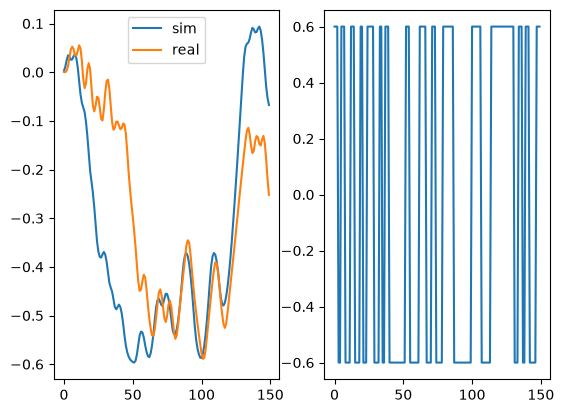

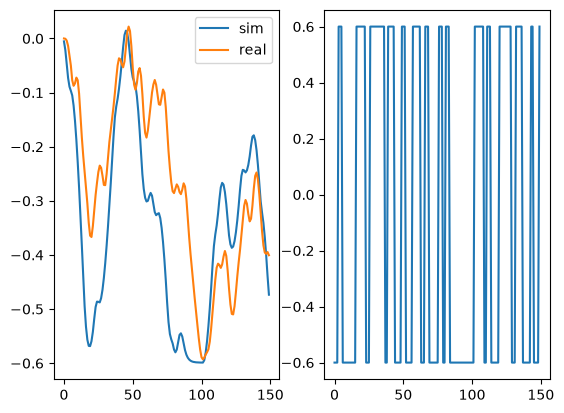

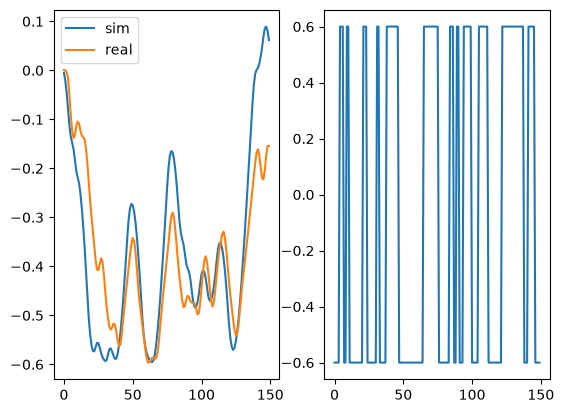

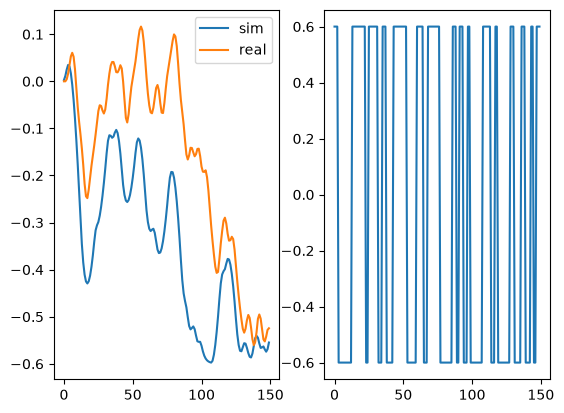

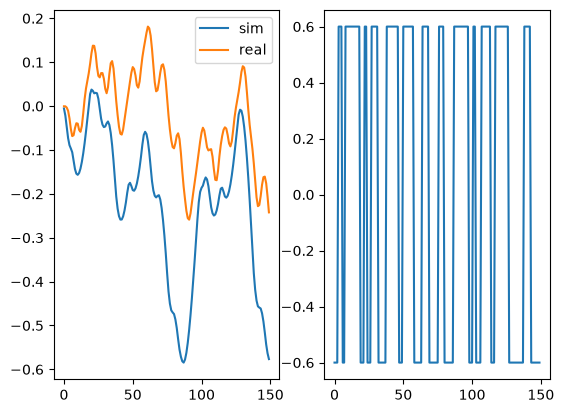

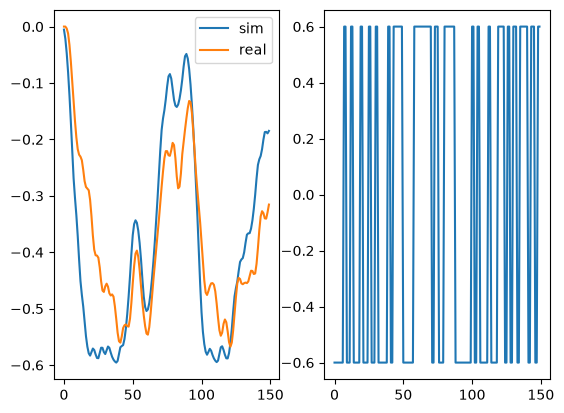

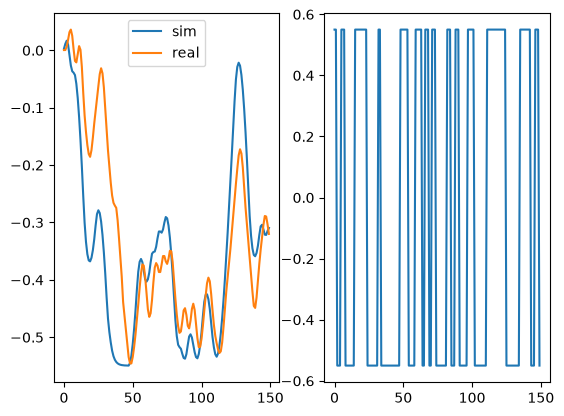

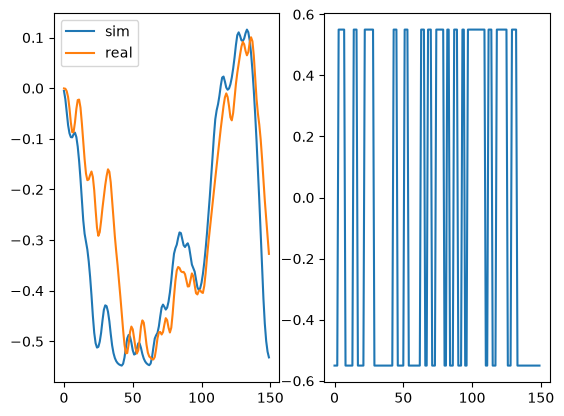

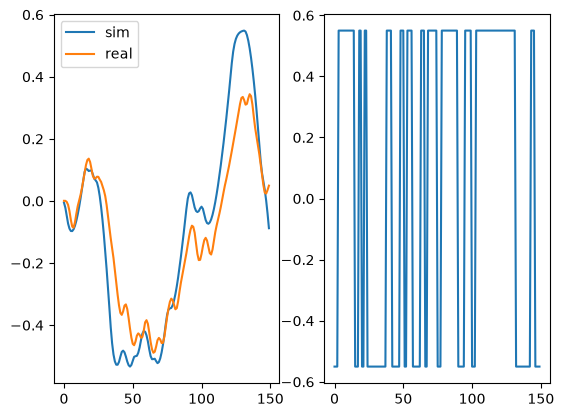

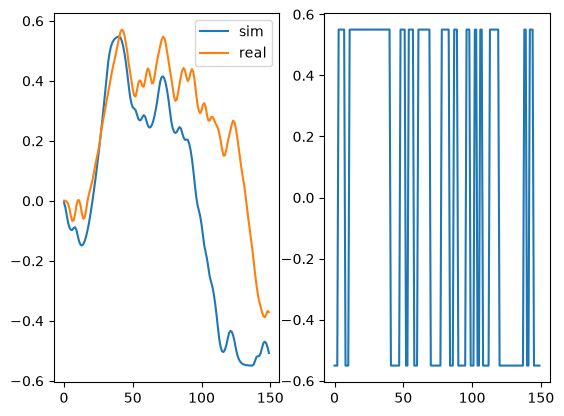

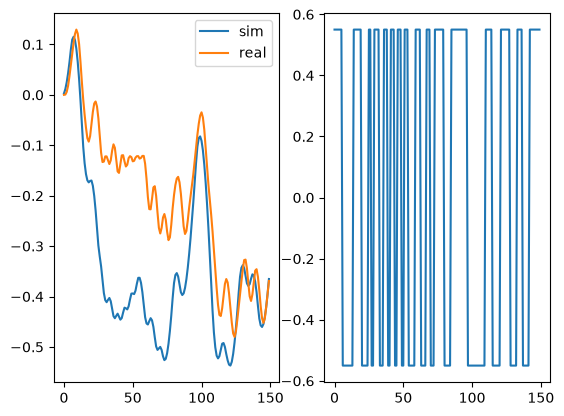

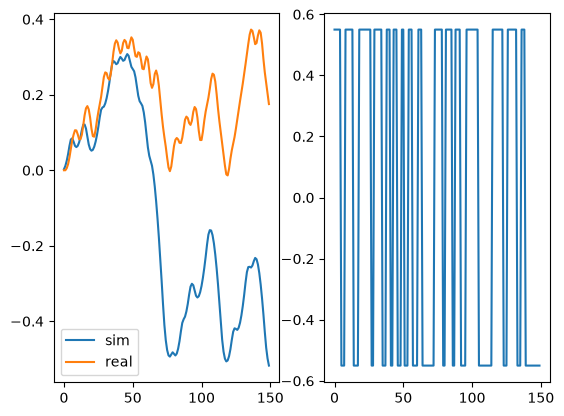

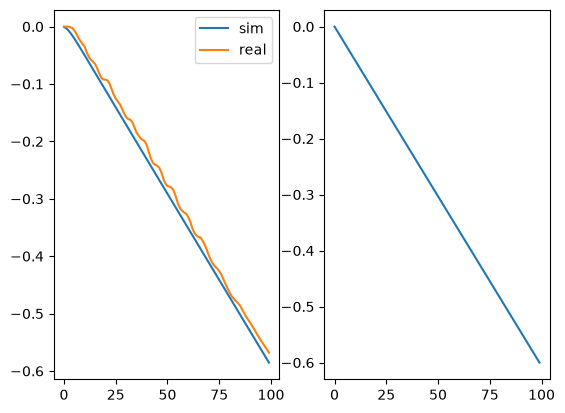

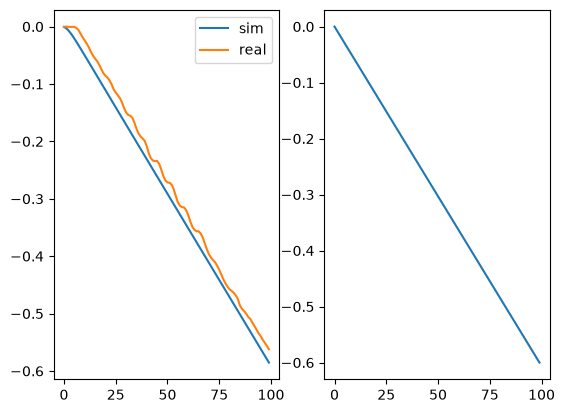

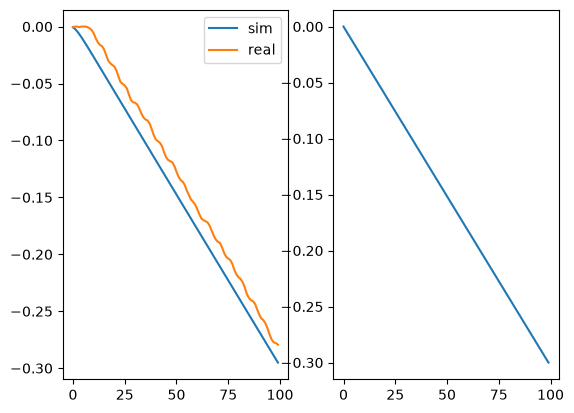

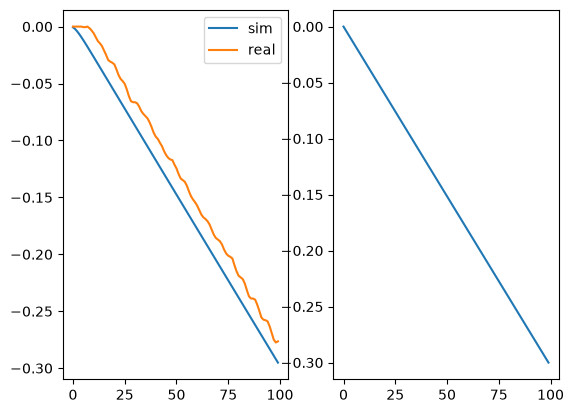

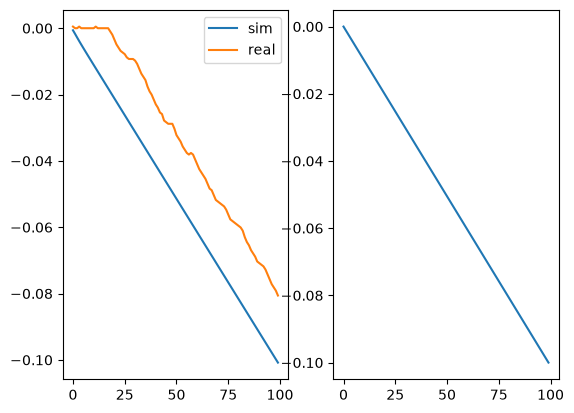

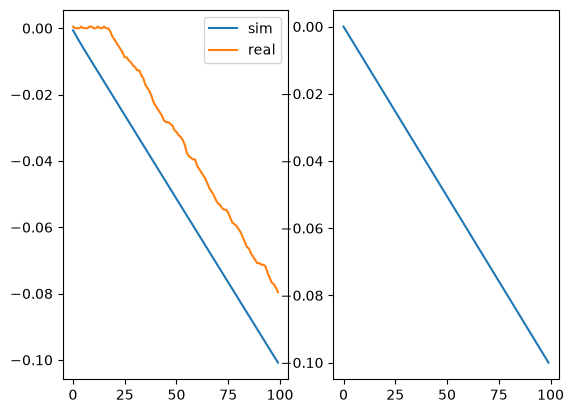

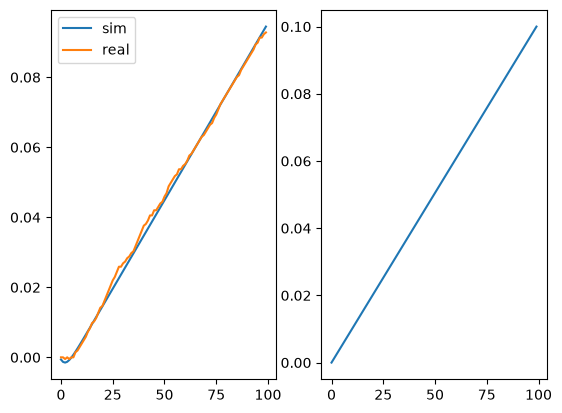

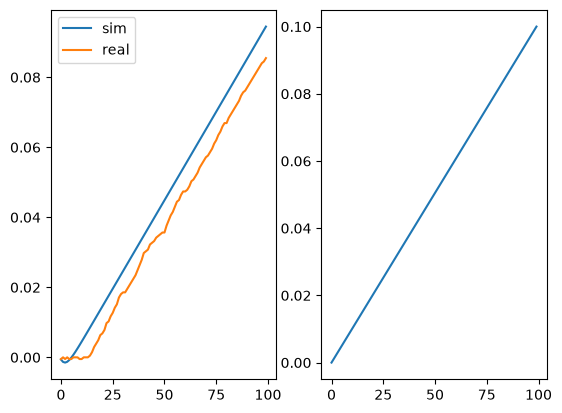

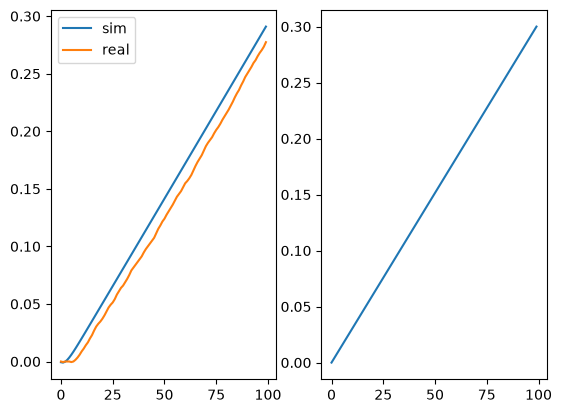

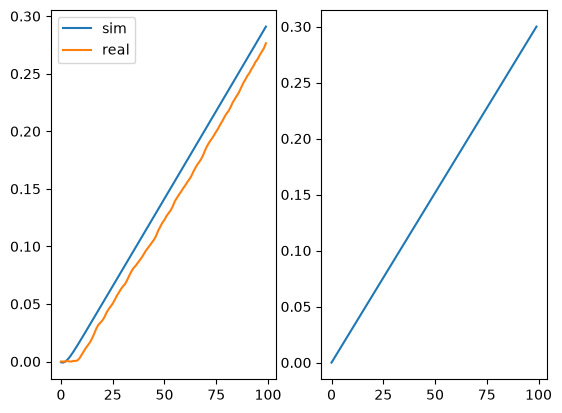

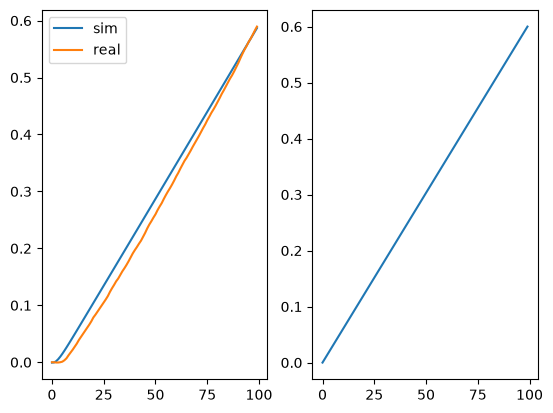

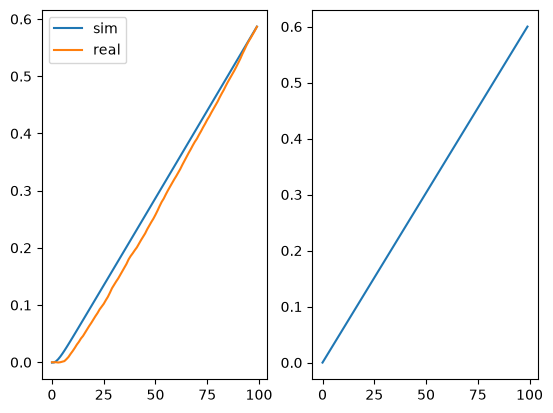

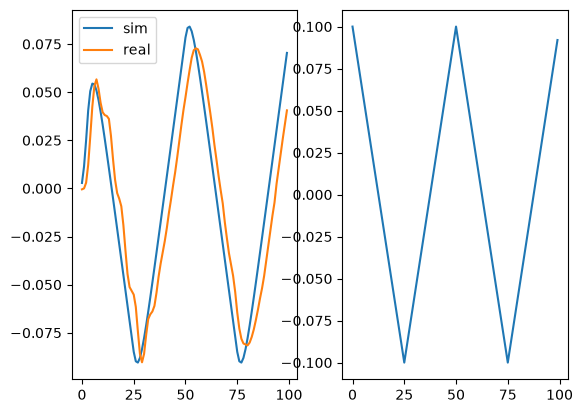

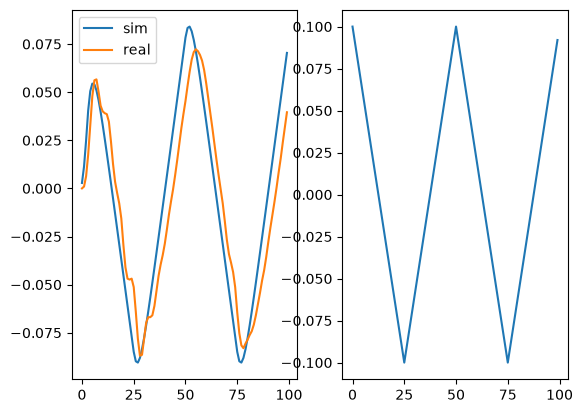

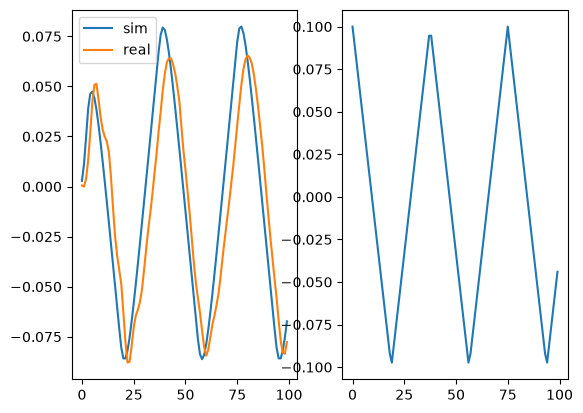

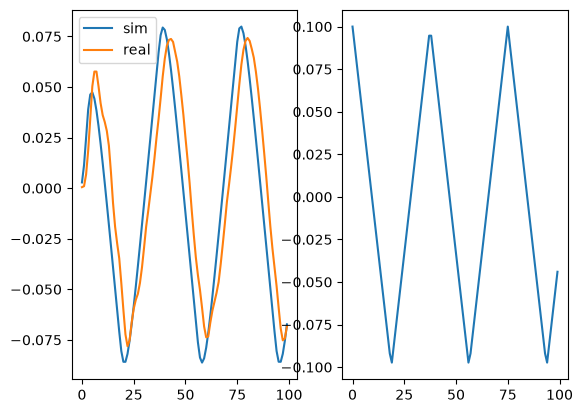

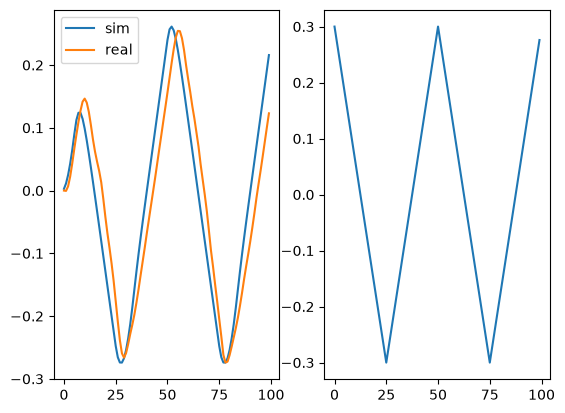

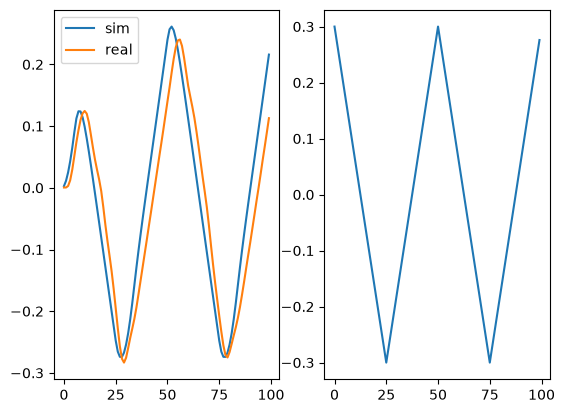

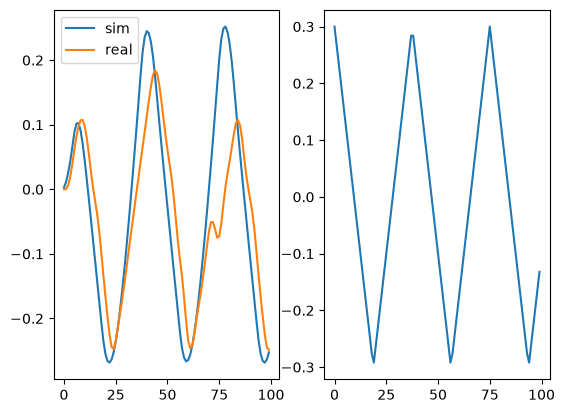

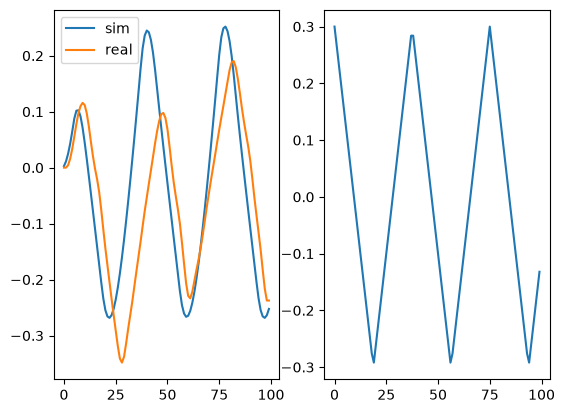

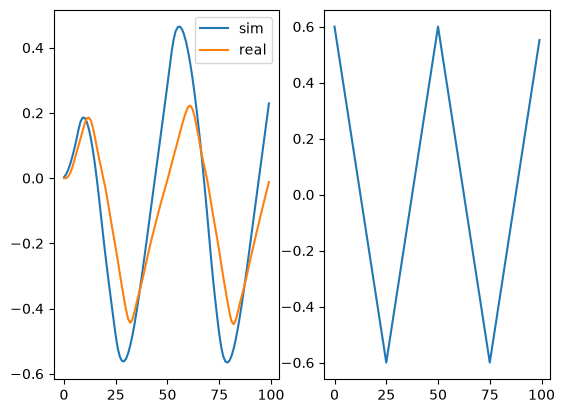

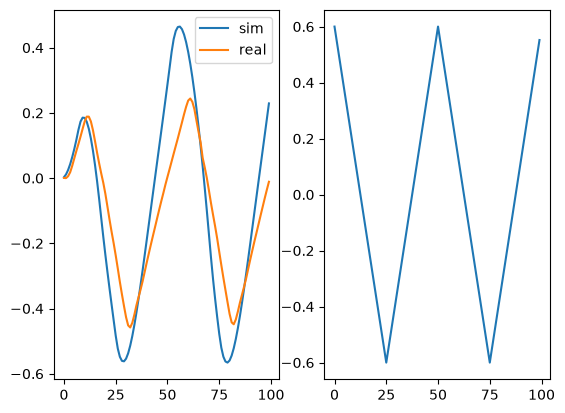

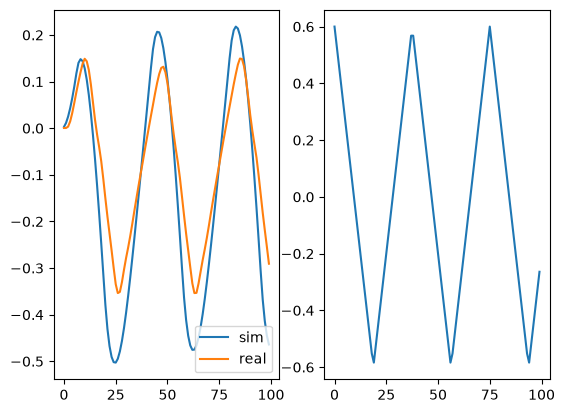

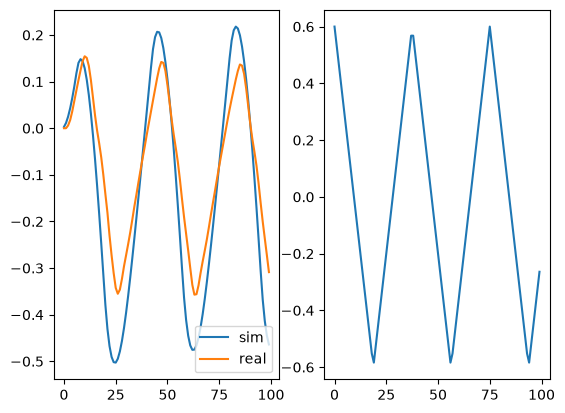

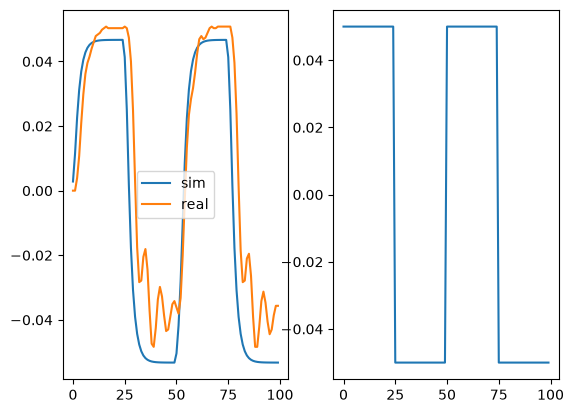

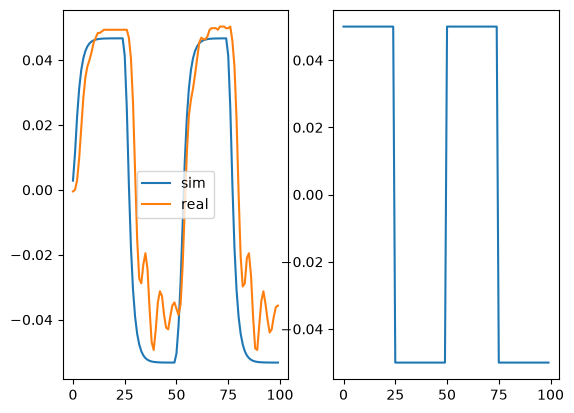

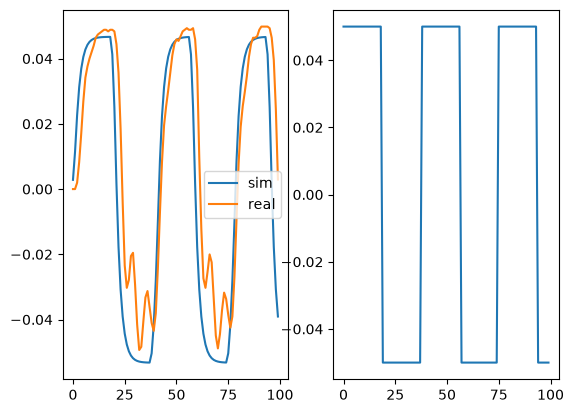

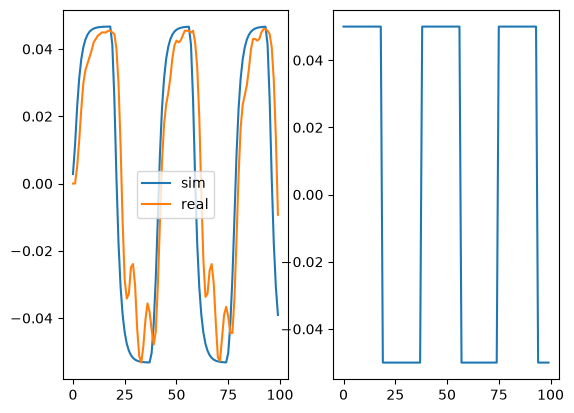

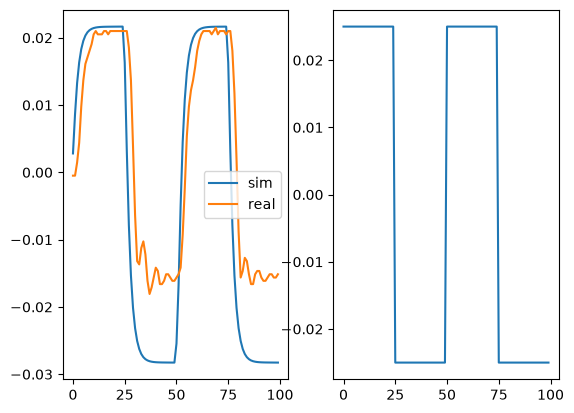

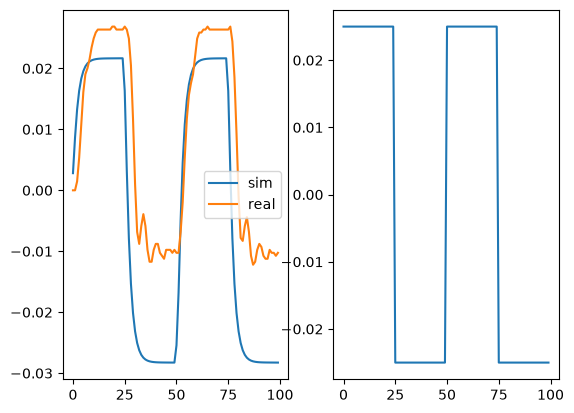

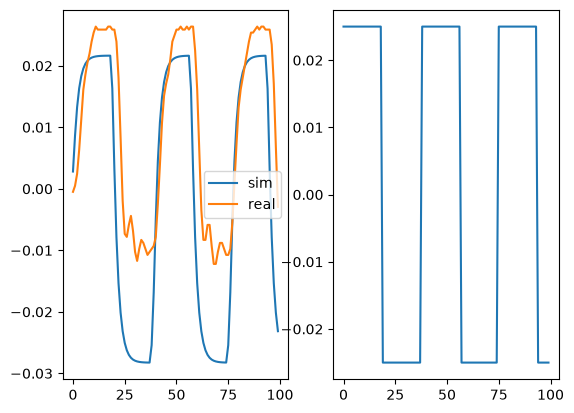

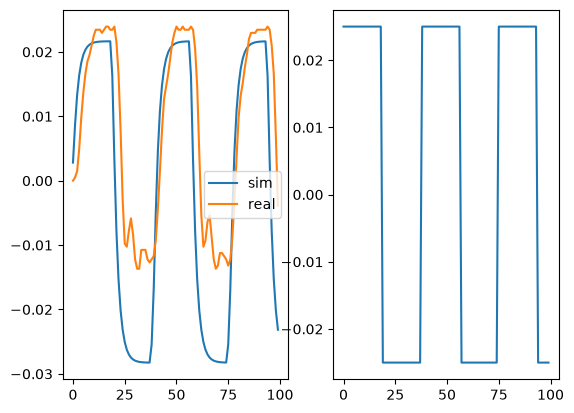

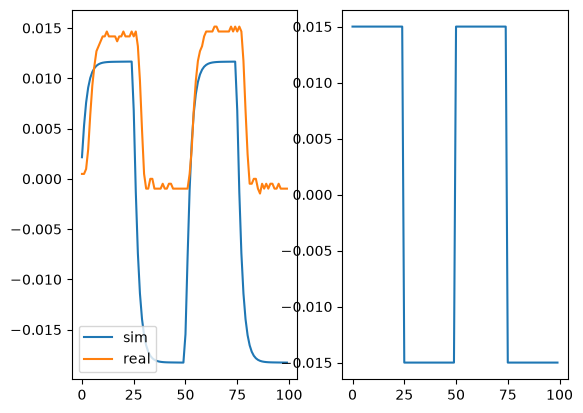

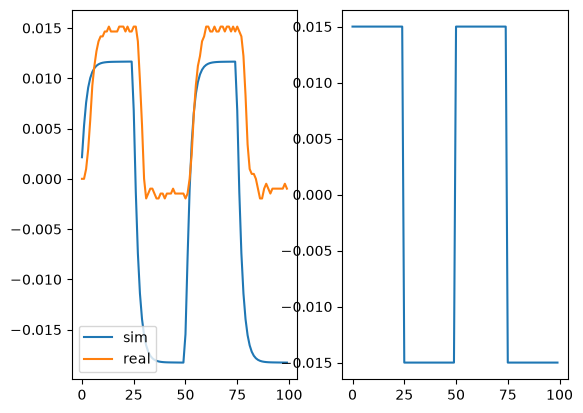

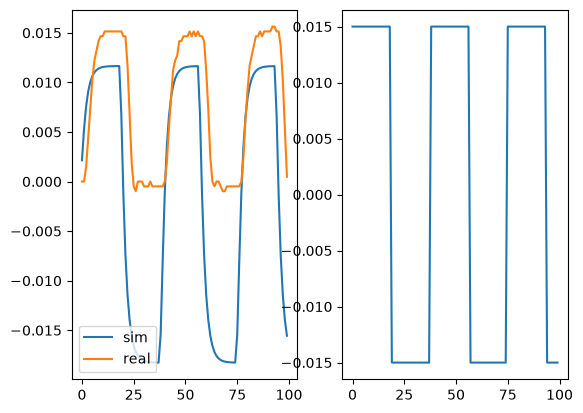

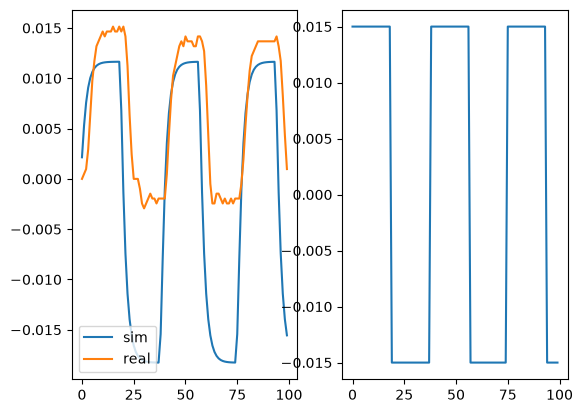

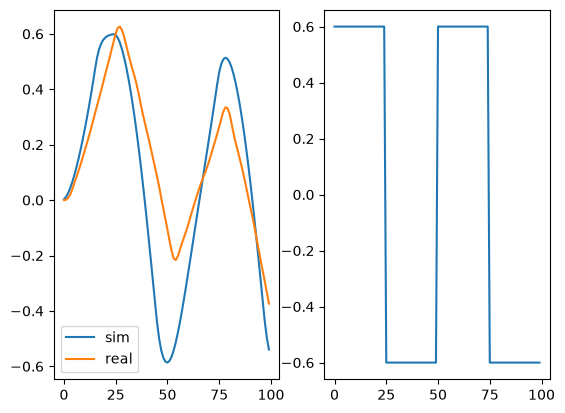

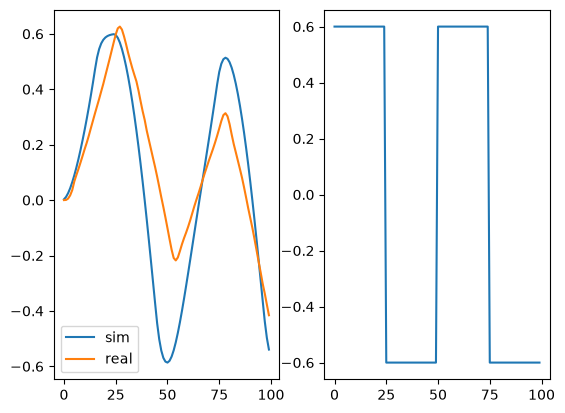

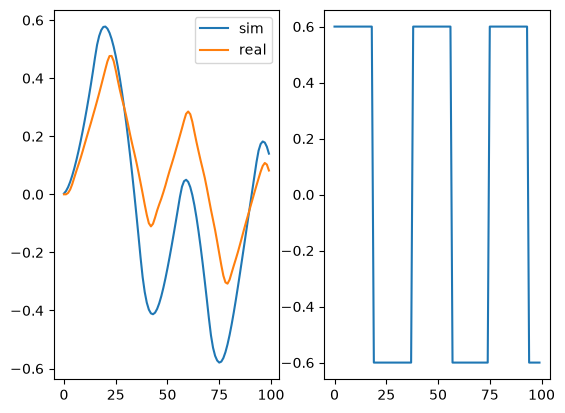

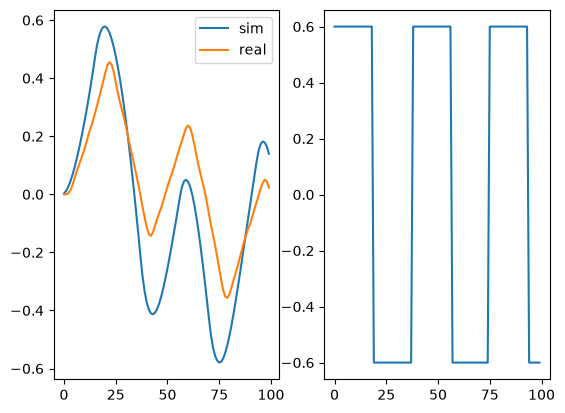

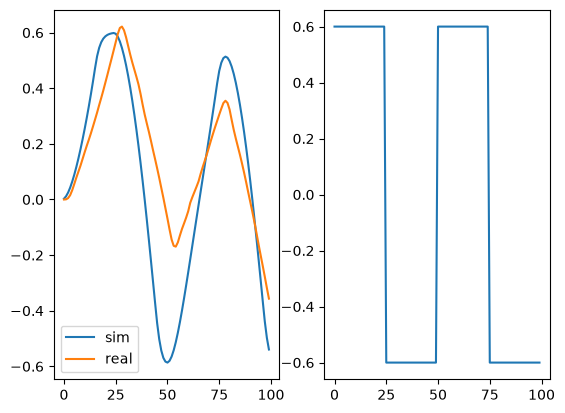

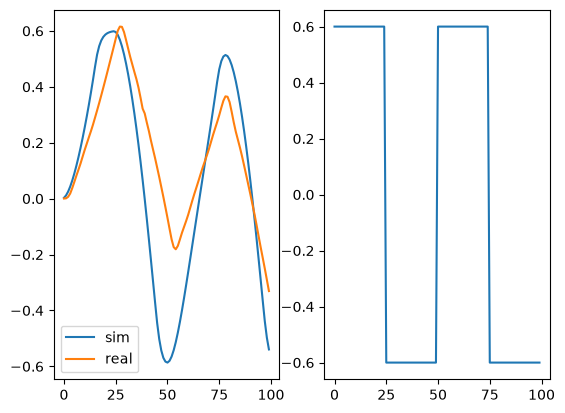

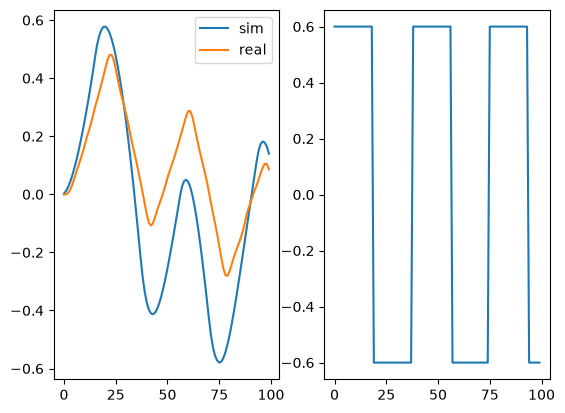

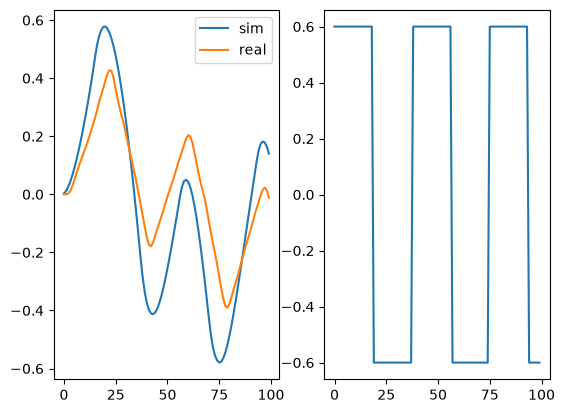

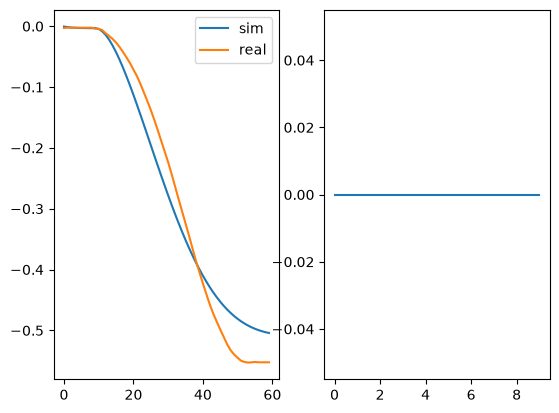

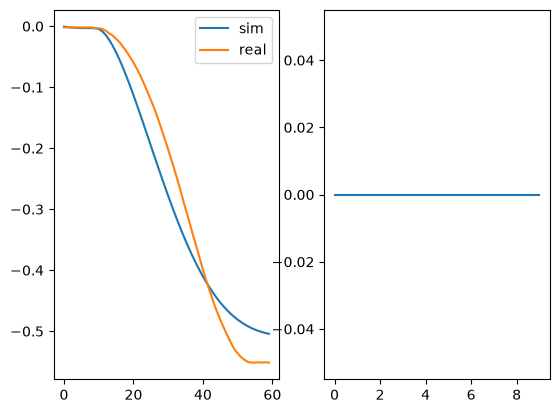

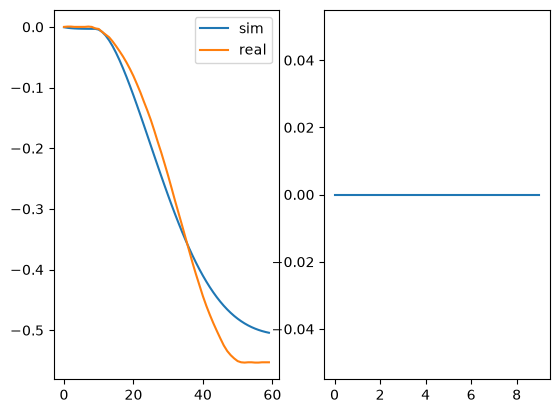

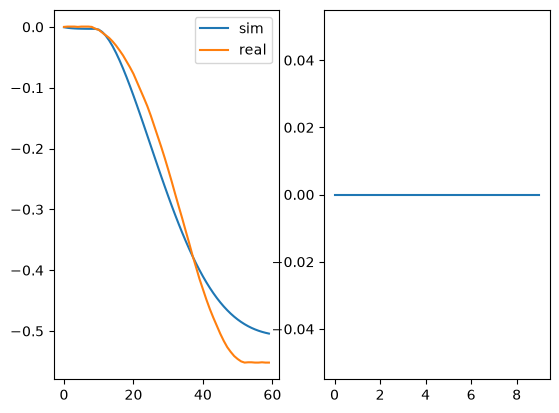

In [25]:

for rollout in data['data']:
    fig, axs = plt.subplots(ncols=2)
    axs[0].plot(rollout['sim_states'])
    axs[0].plot(rollout['real_states'])
    axs[0].legend(['sim', 'real'])
    axs[1].plot(rollout['actions'])
    plt.show()